# Edge Deployment Visualization Studio

This notebook visualizes the **edge-compute deployment benchmarks** produced for the autoencoder models: model size / compression, inference latency, classification fidelity degradation across export formats (TFLite, ONNX, TensorRT), hardware resource usage, and batch-size scaling dynamics.

It reads the single `unified_deployment_report.json` written under `experiments/<model>/deployment/` (keyed by deployment strategy) and saves the generated figures to `docs/plots/`.


In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

EXPERIMENTS_DIR = Path("../experiments")
OUTPUT_DIR = Path("../docs/plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def find_deployment_dirs(root):
    """Return {model_name: deployment_path} for every experiment that has a deployment folder."""
    dirs = {}
    for model_dir in sorted(root.iterdir()):
        dep = model_dir / "deployment"
        if dep.is_dir():
            dirs[model_dir.name] = dep
    return dirs


deployment_dirs = find_deployment_dirs(EXPERIMENTS_DIR)
print(f"Found deployment results for: {', '.join(deployment_dirs) or '(none)'}")

# This notebook focuses on a single model's deployment sweep.
# Change MODEL to any key printed above.
MODEL = next(iter(deployment_dirs))
DEP_DIR = deployment_dirs[MODEL]
print(f"Using model: {MODEL}  ->  {DEP_DIR}")

Found deployment results for: conv1d_ae
Using model: conv1d_ae  ->  ../experiments/conv1d_ae/deployment


In [2]:
# The pipeline now emits a single unified report keyed by deployment strategy.
# Load it and reconstruct the per-suite views that the charts below consume.
def maybe_load(name):
    path = DEP_DIR / name
    return load_json(path) if path.exists() else None


unified_report = maybe_load("unified_deployment_report.json")


def _reconstruct(unified):
    """Split the unified report back into the four per-suite structures."""
    deployment, performance, evaluation, batch = {}, [], [], {}
    for name, rec in (unified or {}).items():
        size_mb = rec.get("size_mb")
        b = rec.get("benchmark")
        if b:
            deployment[name] = {
                "name": name,
                "size_mb": size_mb,
                "latency_bs1_mean": b.get("latency_bs1_mean_ms"),
                "latency_bs1_std": b.get("latency_bs1_std_ms"),
                "latency_bs32_mean": b.get("latency_bs32_mean_ms"),
                "latency_bs32_std": b.get("latency_bs32_std_ms"),
                "mse": b.get("mse"),
                "mse_diff_from_baseline": b.get("mse_diff_from_baseline"),
            }
        if rec.get("performance"):
            performance.append({"model_name": name, "size_mb": size_mb, **rec["performance"]})
        if rec.get("evaluation"):
            evaluation.append({"model_name": name, "size_mb": size_mb, **rec["evaluation"]})
        if rec.get("batch_scaling"):
            batch[name] = rec["batch_scaling"]
    return deployment, performance, evaluation, batch


deployment_report, performance_report, evaluation_report, batch_report = _reconstruct(unified_report)

# A consistent color per model format across every chart.
_all_names = [r["model_name"] for r in (evaluation_report or performance_report or [])]
_palette = plt.cm.tab10(np.linspace(0, 1, max(len(_all_names), 1)))
COLOR = {name: _palette[i % len(_palette)] for i, name in enumerate(_all_names)}


def color_for(name):
    return COLOR.get(name, "#4c72b0")


print(f"Unified report: {'ok' if unified_report else 'MISSING'}  ({len(unified_report or {})} strategies)")
for label, rep in [
    ("deployment", deployment_report),
    ("performance", performance_report),
    ("evaluation", evaluation_report),
    ("batch_size", batch_report),
]:
    print(f"  {label:12s}: {len(rep) if rep else 0} entries")


Unified report: ok  (8 strategies)
  deployment  : 7 entries
  performance : 8 entries
  evaluation  : 8 entries
  batch_size  : 4 entries


## 1. Model Size & Compression
Compares the on-disk footprint of each export format against the FP32 Keras baseline. Quantization (INT8) and pruning-friendly formats trade fidelity for a much smaller deployable size.

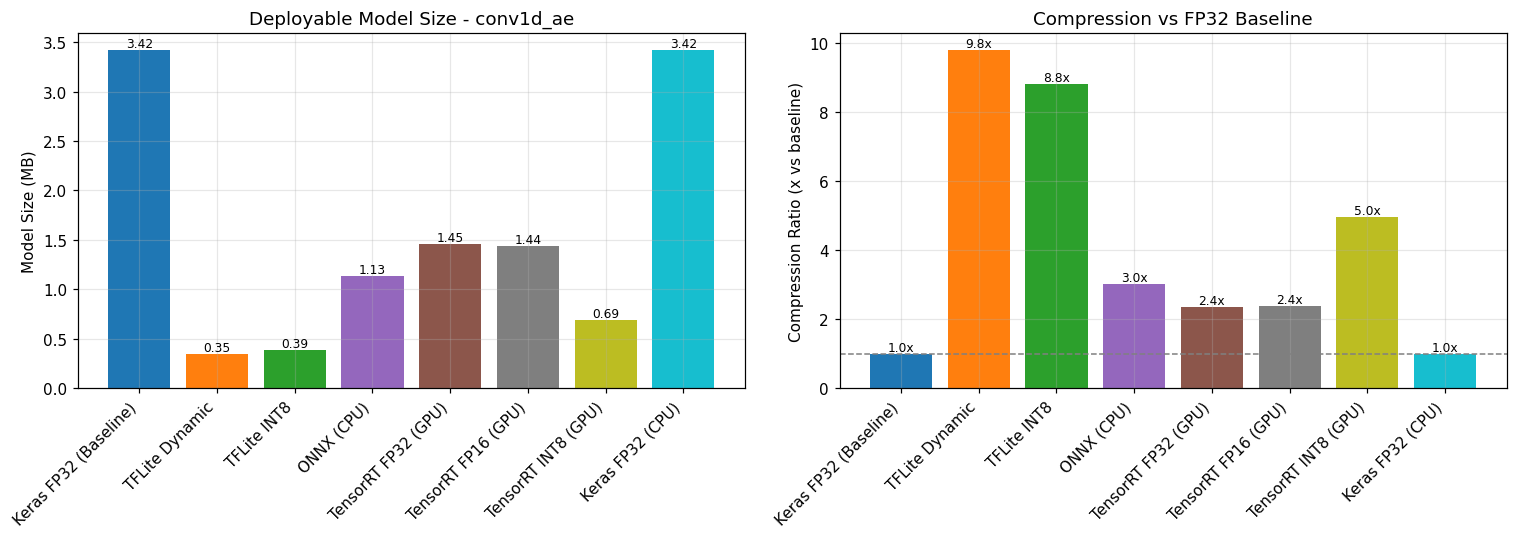

In [3]:
if evaluation_report:
    df = pd.DataFrame(evaluation_report)
    df = df.dropna(subset=["size_mb"]).drop_duplicates(subset=["model_name"])
    baseline_size = df.loc[df["model_name"].str.contains("Baseline"), "size_mb"]
    baseline_size = baseline_size.iloc[0] if len(baseline_size) else df["size_mb"].max()
    df["compression"] = baseline_size / df["size_mb"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    colors = [color_for(n) for n in df["model_name"]]

    ax1.bar(df["model_name"], df["size_mb"], color=colors)
    ax1.set_ylabel("Model Size (MB)")
    ax1.set_title(f"Deployable Model Size - {MODEL}")
    ax1.tick_params(axis="x", rotation=45)
    for i, v in enumerate(df["size_mb"]):
        ax1.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    ax2.bar(df["model_name"], df["compression"], color=colors)
    ax2.axhline(1.0, color="gray", ls="--", lw=1)
    ax2.set_ylabel("Compression Ratio (x vs baseline)")
    ax2.set_title("Compression vs FP32 Baseline")
    ax2.tick_params(axis="x", rotation=45)
    for i, v in enumerate(df["compression"]):
        ax2.text(i, v, f"{v:.1f}x", ha="center", va="bottom", fontsize=8)

    plt.setp(ax1.get_xticklabels(), ha="right")
    plt.setp(ax2.get_xticklabels(), ha="right")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_model_size_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No evaluation_benchmark_report.json available.")

## 2. Inference Latency by Format
Batch-1 (single-sample, latency-critical) vs batch-32 (throughput) latency for each export format, with standard-deviation error bars. GPU formats (TensorRT) collapse the batch-32 penalty.

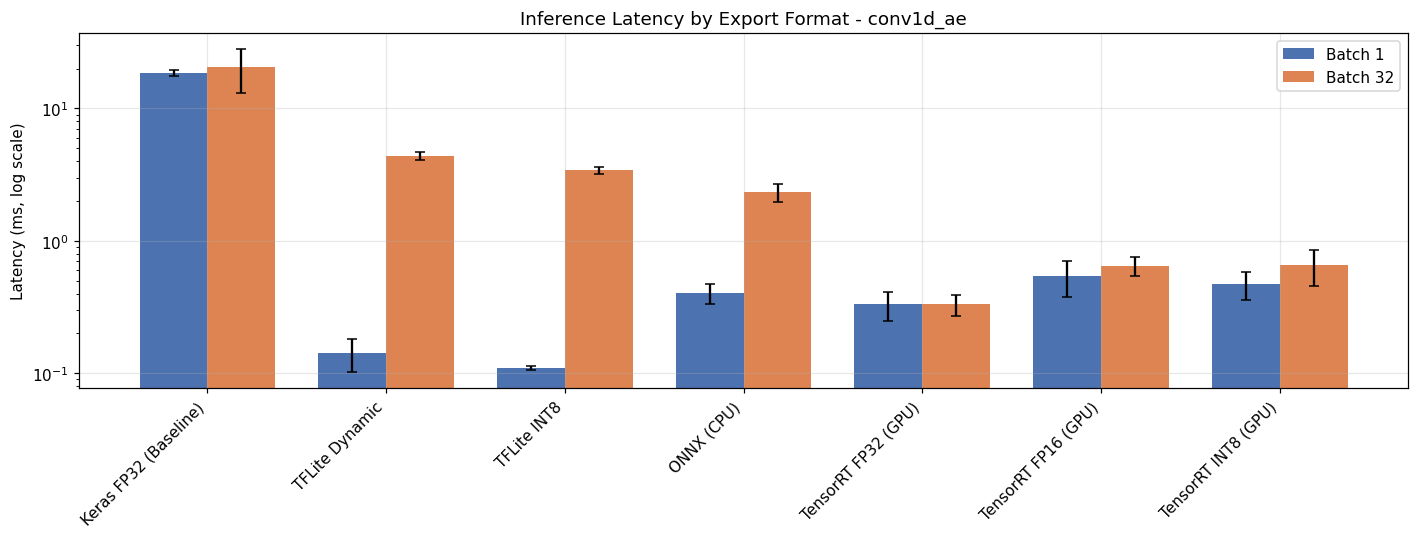

In [4]:
if deployment_report:
    rows = list(deployment_report.values())
    names = [r["name"] for r in rows]
    bs1 = np.array([r["latency_bs1_mean"] for r in rows])
    bs1_std = np.array([r["latency_bs1_std"] for r in rows])
    bs32 = np.array([r["latency_bs32_mean"] for r in rows])
    bs32_std = np.array([r["latency_bs32_std"] for r in rows])

    x = np.arange(len(names))
    w = 0.38
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - w / 2, bs1, w, yerr=bs1_std, capsize=3, label="Batch 1", color="#4c72b0")
    ax.bar(x + w / 2, bs32, w, yerr=bs32_std, capsize=3, label="Batch 32", color="#dd8452")
    ax.set_yscale("log")
    ax.set_ylabel("Latency (ms, log scale)")
    ax.set_title(f"Inference Latency by Export Format - {MODEL}")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_latency_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No deployment_benchmark_report.json available.")

## 3. Classification Fidelity Degradation
How each optimized format affects downstream anomaly-detection quality. Aggressive quantization can keep latency low while silently destroying AUC-ROC / accuracy — this chart surfaces those regressions.

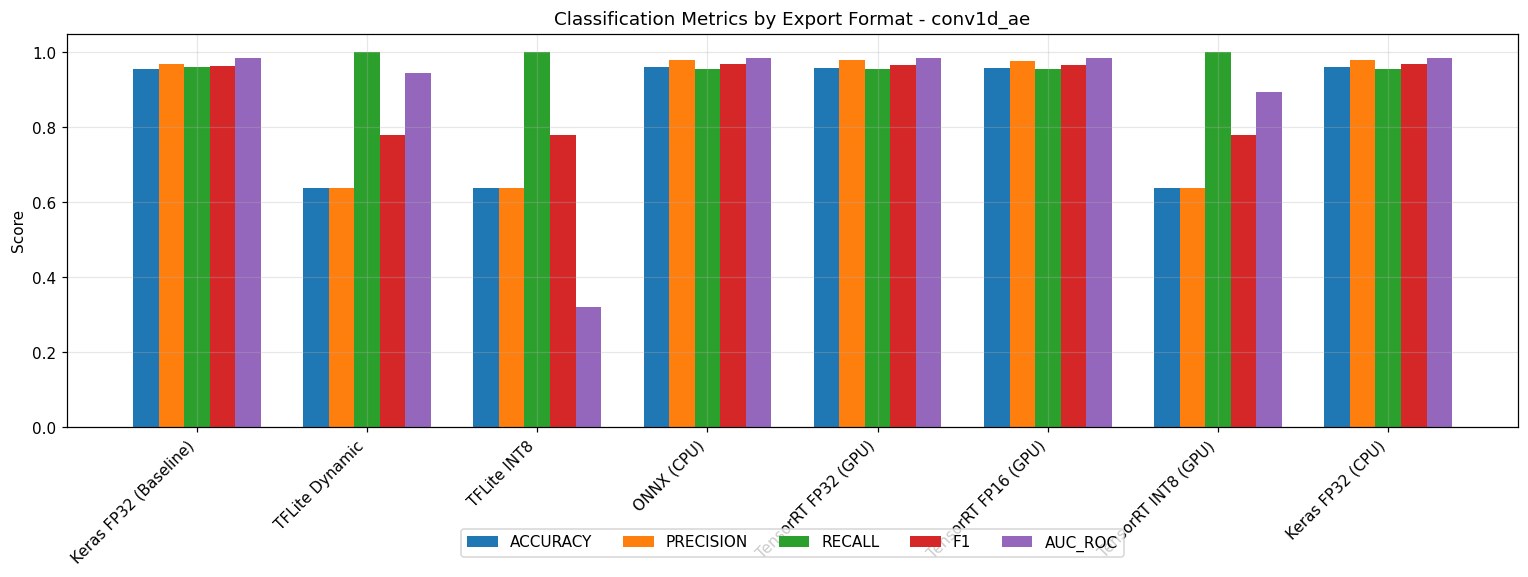

In [5]:
if evaluation_report:
    df = pd.DataFrame(evaluation_report).drop_duplicates(subset=["model_name"])
    metrics = ["accuracy", "precision", "recall", "f1", "auc_roc"]
    names = df["model_name"].tolist()

    x = np.arange(len(names))
    w = 0.15
    fig, ax = plt.subplots(figsize=(14, 5.5))
    for i, m in enumerate(metrics):
        offset = (i - (len(metrics) - 1) / 2) * w
        ax.bar(x + offset, df[m], w, label=m.upper())
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Classification Metrics by Export Format - {MODEL}")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.35))
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_metrics_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No evaluation_benchmark_report.json available.")

## 4. Reconstruction Fidelity Shift
Reconstruction MSE per format and the absolute drift from the FP32 baseline. A large MSE shift is an early warning that a quantized model has diverged from the reference behaviour.

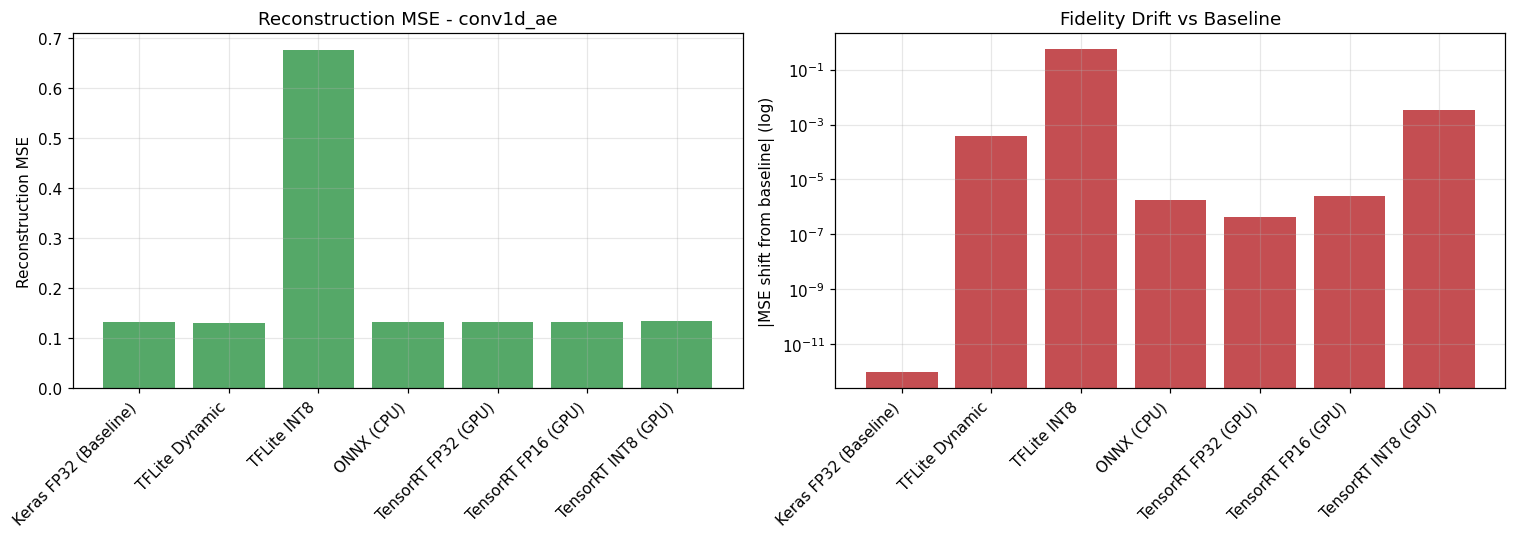

In [6]:
if deployment_report:
    rows = list(deployment_report.values())
    names = [r["name"] for r in rows]
    mse = np.array([r["mse"] for r in rows])
    mse_diff = np.array([abs(r["mse_diff_from_baseline"]) for r in rows])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.bar(names, mse, color="#55a868")
    ax1.set_ylabel("Reconstruction MSE")
    ax1.set_title(f"Reconstruction MSE - {MODEL}")
    ax1.tick_params(axis="x", rotation=45)
    plt.setp(ax1.get_xticklabels(), ha="right")

    mse_diff_plot = np.where(mse_diff <= 0, 1e-12, mse_diff)
    ax2.bar(names, mse_diff_plot, color="#c44e52")
    ax2.set_yscale("log")
    ax2.set_ylabel("|MSE shift from baseline| (log)")
    ax2.set_title("Fidelity Drift vs Baseline")
    ax2.tick_params(axis="x", rotation=45)
    plt.setp(ax2.get_xticklabels(), ha="right")

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_mse_shift_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No deployment_benchmark_report.json available.")

## 5. Hardware Resource Profiling
Measured single-inference latency (mean with min/max whiskers) and peak memory footprint per format. Useful for sizing the target edge device.

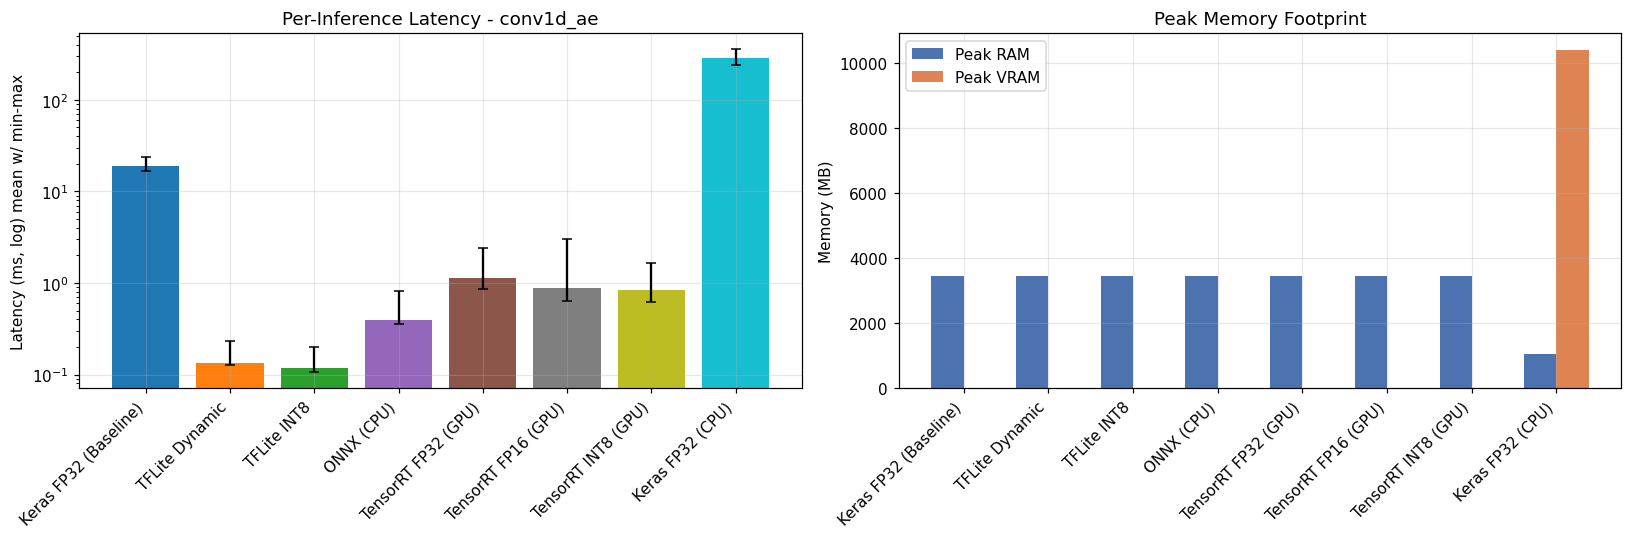

In [7]:
if performance_report:
    df = pd.DataFrame(performance_report).drop_duplicates(subset=["model_name"])
    names = df["model_name"].tolist()
    mean = df["latency_mean_ms"].to_numpy()
    lo = mean - df["latency_min_ms"].to_numpy()
    hi = df["latency_max_ms"].to_numpy() - mean

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    colors = [color_for(n) for n in names]
    ax1.bar(names, mean, yerr=[lo, hi], capsize=3, color=colors)
    ax1.set_yscale("log")
    ax1.set_ylabel("Latency (ms, log) mean w/ min-max")
    ax1.set_title(f"Per-Inference Latency - {MODEL}")
    ax1.tick_params(axis="x", rotation=45)
    plt.setp(ax1.get_xticklabels(), ha="right")

    xw = np.arange(len(names))
    w = 0.38
    ax2.bar(xw - w / 2, df["peak_ram_mb"], w, label="Peak RAM", color="#4c72b0")
    ax2.bar(xw + w / 2, df["peak_vram_mb"], w, label="Peak VRAM", color="#dd8452")
    ax2.set_ylabel("Memory (MB)")
    ax2.set_title("Peak Memory Footprint")
    ax2.set_xticks(xw)
    ax2.set_xticklabels(names, rotation=45, ha="right")
    ax2.legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_hardware_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No performance_benchmark_report.json available.")

## 6. Batch-Size Scaling Dynamics
How batch and per-sample latency evolve as batch size grows. Flat per-sample curves indicate the format is already compute-bound; steep drops indicate amortization headroom.

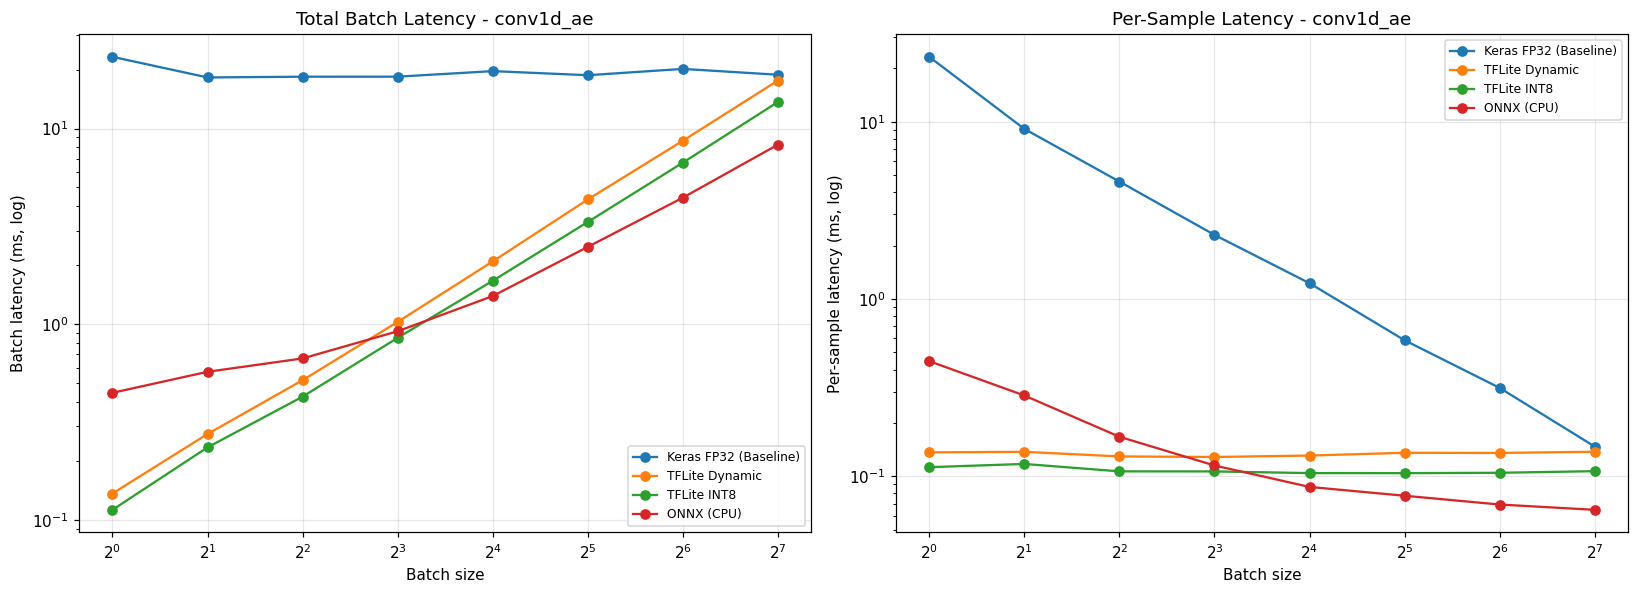

In [8]:
if batch_report:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
    for model_name, sweep in batch_report.items():
        sizes = sorted(int(b) for b in sweep)
        batch_lat = [sweep[str(b)]["latency_batch_ms"] for b in sizes]
        sample_lat = [sweep[str(b)]["latency_sample_ms"] for b in sizes]
        ax1.plot(sizes, batch_lat, marker="o", label=model_name)
        ax2.plot(sizes, sample_lat, marker="o", label=model_name)

    for ax, title, ylabel in [
        (ax1, "Total Batch Latency", "Batch latency (ms, log)"),
        (ax2, "Per-Sample Latency", "Per-sample latency (ms, log)"),
    ]:
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xlabel("Batch size")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title} - {MODEL}")
        ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_batch_scaling_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No batch_size_study_report.json available.")

## 7. Size / Latency / Accuracy Trade-off
A single Pareto-style view: each format positioned by model size (x) and per-sample latency (y), coloured by accuracy. The bottom-left, brightest points are the best deployment candidates.

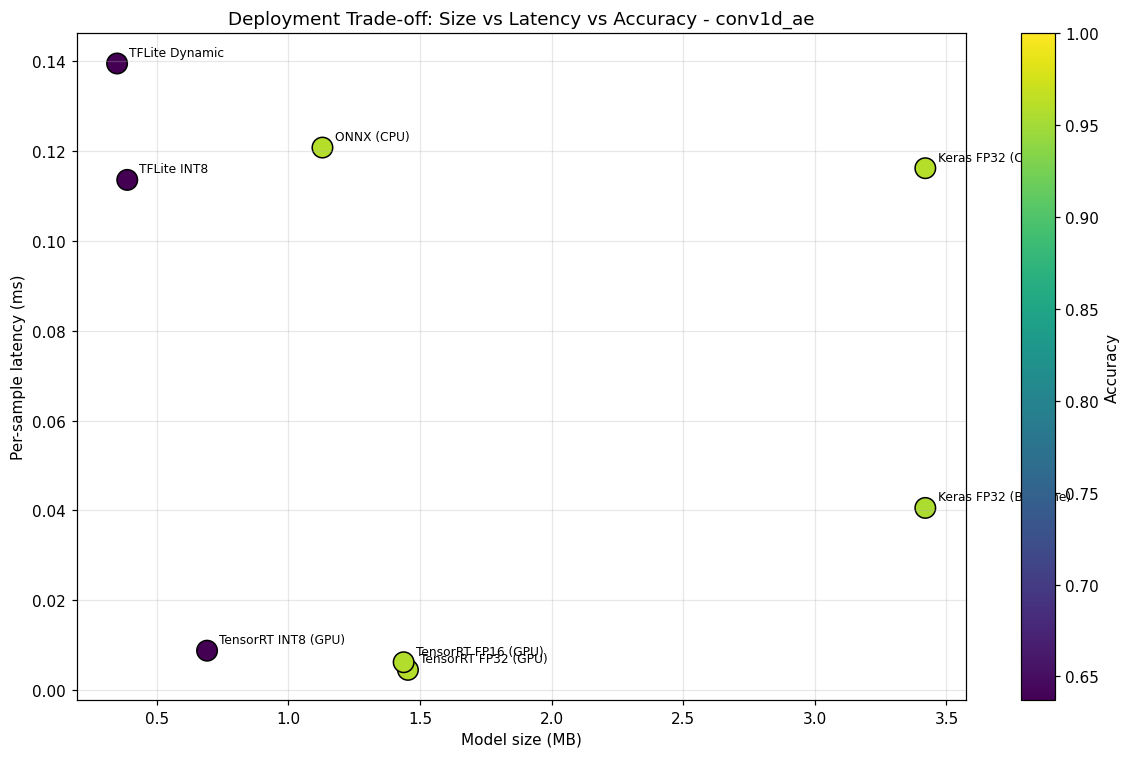

In [9]:
if evaluation_report:
    df = pd.DataFrame(evaluation_report).drop_duplicates(subset=["model_name"])
    df = df.dropna(subset=["size_mb", "latency_per_sample_mean_ms", "accuracy"])

    fig, ax = plt.subplots(figsize=(11, 7))
    sc = ax.scatter(
        df["size_mb"],
        df["latency_per_sample_mean_ms"],
        c=df["accuracy"],
        s=180,
        cmap="viridis",
        edgecolors="black",
        vmin=df["accuracy"].min(),
        vmax=1.0,
    )
    for _, row in df.iterrows():
        ax.annotate(
            row["model_name"],
            (row["size_mb"], row["latency_per_sample_mean_ms"]),
            textcoords="offset points",
            xytext=(8, 5),
            fontsize=8,
        )
    ax.set_xlabel("Model size (MB)")
    ax.set_ylabel("Per-sample latency (ms)")
    ax.set_title(f"Deployment Trade-off: Size vs Latency vs Accuracy - {MODEL}")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Accuracy")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_tradeoff_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No evaluation_benchmark_report.json available.")

## 8. Summary Table
Consolidated per-format view combining size, latency, and classification metrics for quick reference.

In [10]:
if evaluation_report:
    summary = pd.DataFrame(evaluation_report).drop_duplicates(subset=["model_name"])
    cols = [
        "model_name",
        "size_mb",
        "latency_per_sample_mean_ms",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc_roc",
    ]
    summary = summary[[c for c in cols if c in summary.columns]].round(4)
    display(summary.reset_index(drop=True))
else:
    print("No evaluation_benchmark_report.json available.")

,model_name,size_mb,latency_per_sample_mean_ms,accuracy,precision,recall,f1,auc_roc
0,Keras FP32 (Baseline),3.4198,0.0406,0.9555,0.9702,0.9596,0.9649,0.9851
1,TFLite Dynamic,0.3490,0.1395,0.6371,0.6371,1.0000,0.7783,0.9446
2,TFLite INT8,0.3876,0.1136,0.6371,0.6371,1.0000,0.7783,0.3213
3,ONNX (CPU),1.1292,0.1208,0.9600,0.9801,0.9568,0.9683,0.9861
4,TensorRT FP32 (GPU),1.4540,0.0045,0.9590,0.9784,0.9568,0.9675,0.9854
5,TensorRT FP16 (GPU),1.4377,0.0062,0.9588,0.9780,0.9569,0.9673,0.9852
6,TensorRT INT8 (GPU),0.6908,0.0088,0.6371,0.6371,1.0000,0.7783,0.8946
7,Keras FP32 (CPU),3.4198,0.1162,0.9600,0.9800,0.9567,0.9682,0.9861
